# 🔍 Fraud Detection — Exploratory Data Analysis

**Objective:** Identify patterns, biases, and high-signal features for fraud detection model training.  
**Dataset:** 210K banking transactions merged with card & user demographic data.  
**Class balance:** ~0.15% fraud (315/210,000) — heavily imbalanced.

---

## EDA Roadmap
1. **Data Loading & Schema Audit** — types, nulls, cardinality
2. **Target Distribution** — fraud rate, class imbalance
3. **Amount Analysis** — distribution, fraud vs legit, outliers
4. **Temporal Patterns** — hour-of-day, day-of-week, monthly trends
5. **Transaction Channel** — use_chip (Chip/Swipe/Online) fraud rates
6. **Merchant Category (MCC)** — fraud concentration by category
7. **Geographic Analysis** — state-level fraud rates, foreign transactions
8. **Card & User Profile** — card type, brand, age, income vs fraud
9. **Error Signals** — correlation between errors and fraud
10. **Feature Importance Preview** — correlation heatmap, mutual info
11. **Feature Engineering Roadmap** — what to build for modeling

---
## 1 · Data Loading & Schema Audit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Style ──
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('.')
print('✓ Libraries loaded')

✓ Libraries loaded


In [2]:
# ── Load raw sources (from data_pipeline.py logic) ──
users = pd.read_csv(DATA_DIR / 'users_data.csv').rename(columns={'id': 'client_id'})
cards = pd.read_csv(DATA_DIR / 'cards_data.csv').rename(columns={'id': 'card_id'})
txn   = pd.read_csv(DATA_DIR / 'transactions_train.csv')

# Merge cards ← users
cards_users = pd.merge(cards, users, on='client_id', how='left', suffixes=('_card', '_user'))

# Merge transactions ← cards_users
df = pd.merge(txn, cards_users, on=['client_id', 'card_id'], how='left', suffixes=('_txn', '_card'))

# ── Load fraud labels ──
with open(DATA_DIR / 'train_fraud_labels.json') as f:
    labels = json.load(f)['target']

df['is_fraud'] = df['transaction_id'].astype(str).map(labels).map({'Yes': 1, 'No': 0}).astype(int)

# ── Load MCC code descriptions ──
with open(DATA_DIR / 'mcc_codes.json') as f:
    mcc_map = json.load(f)

df['mcc_desc'] = df['mcc'].astype(str).map(mcc_map)

print(f'Shape: {df.shape}')
print(f'Fraud: {df.is_fraud.sum()} / {len(df)} ({df.is_fraud.mean()*100:.3f}%)')

Shape: (210000, 38)
Fraud: 315 / 210000 (0.150%)


In [3]:
# ── Parse amount (strip $ sign) ──
df['amount_clean'] = df['amount'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# ── Parse credit_limit ──
df['credit_limit_clean'] = df['credit_limit'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# ── Parse monetary columns from user data ──
for col in ['per_capita_income', 'yearly_income', 'total_debt']:
    df[f'{col}_clean'] = df[col].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# ── Parse datetime ──
df['datetime'] = pd.to_datetime(df['date'])
df['hour']     = df['datetime'].dt.hour
df['dow']      = df['datetime'].dt.dayofweek  # 0=Mon
df['month']    = df['datetime'].dt.month
df['year']     = df['datetime'].dt.year
df['day_name'] = df['datetime'].dt.day_name()

print('✓ Columns parsed')
df.dtypes

✓ Columns parsed


transaction_id                      int64
date                               object
client_id                           int64
card_id                             int64
amount                             object
use_chip                           object
merchant_id                         int64
merchant_city                      object
merchant_state                     object
zip                               float64
mcc                                 int64
errors                             object
card_brand                         object
card_type                          object
card_number                         int64
expires                            object
cvv                                 int64
has_chip                           object
num_cards_issued                    int64
credit_limit                       object
acct_open_date                     object
year_pin_last_changed               int64
card_on_dark_web                   object
current_age                       

In [4]:
# ── Schema overview ──
schema = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'nunique': df.nunique(),
    'sample': df.iloc[0]
})
schema

,dtype,non_null,null_pct,nunique,sample
transaction_id,int64,210000,0.00,210000,19765990
date,object,210000,0.00,192206,2017-07-07 09:53:00
client_id,int64,210000,0.00,852,1581
card_id,int64,210000,0.00,2538,2519
amount,object,210000,0.00,21399,$12.35
use_chip,object,210000,0.00,3,Chip Transaction
merchant_id,int64,210000,0.00,13576,20519
merchant_city,object,210000,0.00,5472,Arnold
merchant_state,object,184569,12.11,122,MO
zip,float64,183203,12.76,10263,63010.0


---
## 2 · Target Distribution — Class Imbalance

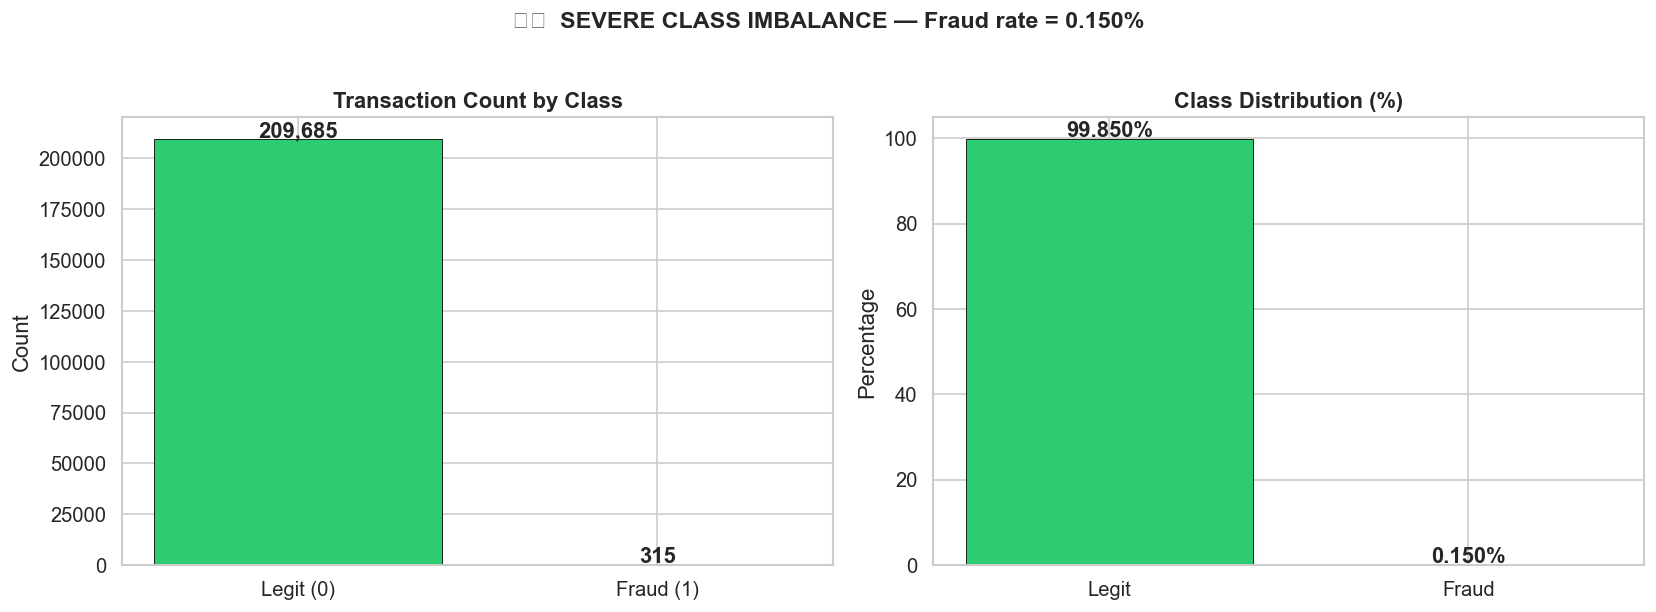


Imbalance ratio: 1:665
→ Will need: SMOTE / class weights / focal loss / threshold tuning


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
vc = df['is_fraud'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legit (0)', 'Fraud (1)'], vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Percentage (log scale visual)
pcts = [100 - df.is_fraud.mean()*100, df.is_fraud.mean()*100]
axes[1].bar(['Legit', 'Fraud'], pcts, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Class Distribution (%)', fontweight='bold')
axes[1].set_ylabel('Percentage')
for i, v in enumerate(pcts):
    axes[1].text(i, v + 0.5, f'{v:.3f}%', ha='center', fontweight='bold')

plt.suptitle(f'⚠️  SEVERE CLASS IMBALANCE — Fraud rate = {df.is_fraud.mean()*100:.3f}%',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nImbalance ratio: 1:{int(vc[0]/vc[1])}')
print('→ Will need: SMOTE / class weights / focal loss / threshold tuning')

---
## 3 · Amount Analysis

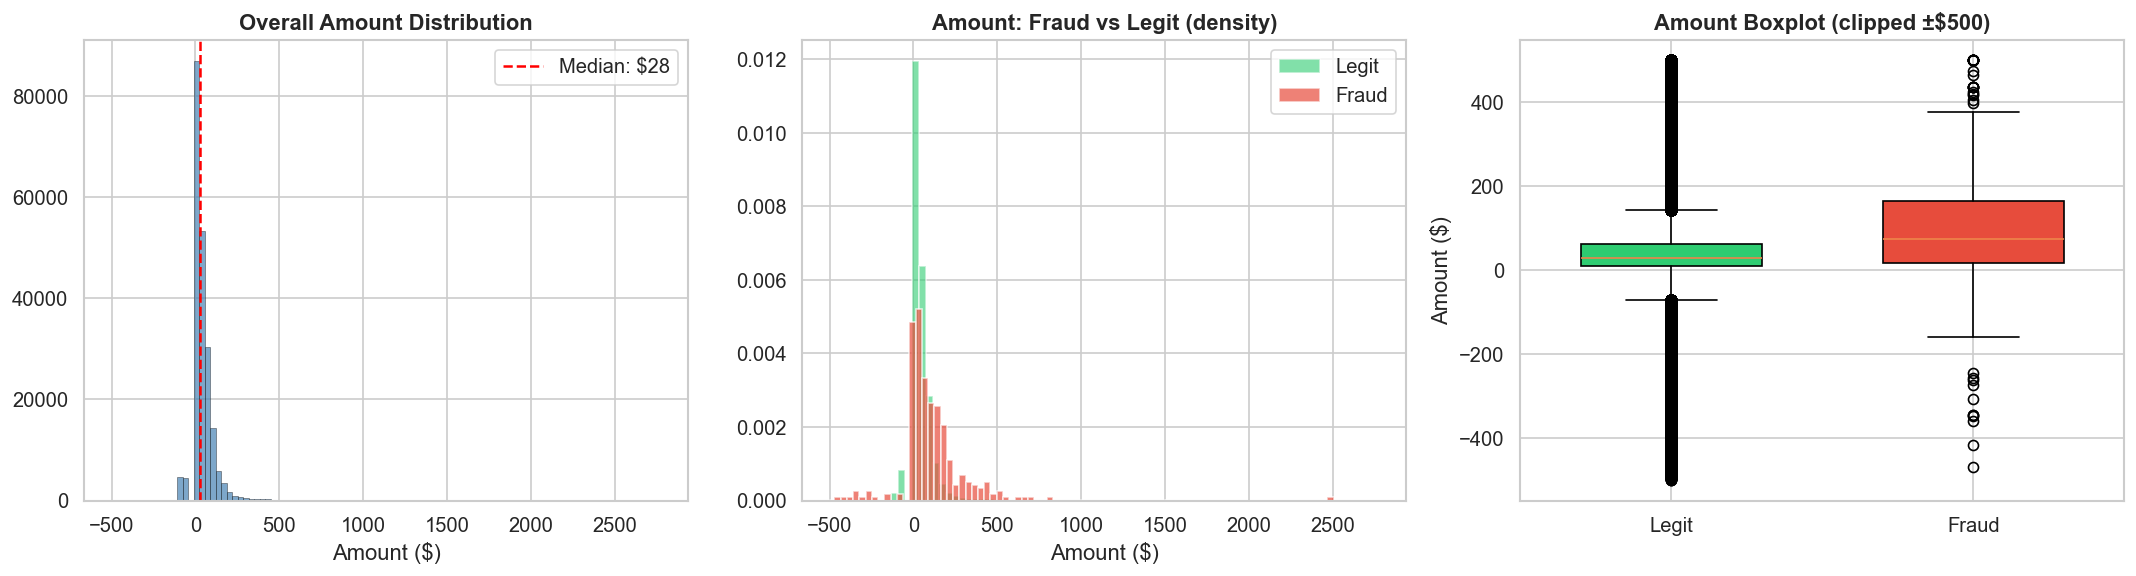


── Amount Statistics ──
           Legit    Fraud
count  209685.00   315.00
mean       42.45   111.91
std        80.27   210.47
min      -500.00  -471.00
25%         8.72    15.68
50%        28.14    73.32
75%        62.15   164.48
max      2775.67  2505.58


In [6]:
fraud_df = df[df.is_fraud == 1]
legit_df = df[df.is_fraud == 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. Overall amount distribution
axes[0].hist(df['amount_clean'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0].set_title('Overall Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].axvline(df['amount_clean'].median(), color='red', ls='--', label=f'Median: ${df.amount_clean.median():.0f}')
axes[0].legend()

# 3b. Fraud vs Legit amount (log scale)
axes[1].hist(legit_df['amount_clean'], bins=80, alpha=0.6, label='Legit', color='#2ecc71', density=True)
axes[1].hist(fraud_df['amount_clean'], bins=80, alpha=0.7, label='Fraud', color='#e74c3c', density=True)
axes[1].set_title('Amount: Fraud vs Legit (density)', fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].legend()

# 3c. Box plot comparison
data_box = [legit_df['amount_clean'].clip(-500, 500), fraud_df['amount_clean'].clip(-500, 500)]
bp = axes[2].boxplot(data_box, labels=['Legit', 'Fraud'], patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[2].set_title('Amount Boxplot (clipped ±$500)', fontweight='bold')
axes[2].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

# Stats table
print('\n── Amount Statistics ──')
stats = pd.DataFrame({
    'Legit': legit_df['amount_clean'].describe(),
    'Fraud': fraud_df['amount_clean'].describe()
}).round(2)
print(stats)

In [7]:
# ── Negative amounts (refunds/chargebacks) ──
neg_mask = df['amount_clean'] < 0
print(f'Negative amounts: {neg_mask.sum()} ({neg_mask.mean()*100:.2f}%)')
print(f'Fraud rate in negative amounts: {df.loc[neg_mask, "is_fraud"].mean()*100:.2f}%')
print(f'Fraud rate in positive amounts: {df.loc[~neg_mask, "is_fraud"].mean()*100:.2f}%')

# ── Zero amounts ──
zero_mask = df['amount_clean'] == 0
print(f'\nZero amounts: {zero_mask.sum()} ({zero_mask.mean()*100:.2f}%)')
print(f'Fraud rate in zero amounts: {df.loc[zero_mask, "is_fraud"].mean()*100:.2f}%')

# ── Amount percentile fraud rates ──
df['amount_bin'] = pd.qcut(df['amount_clean'].clip(lower=0.01), q=10, duplicates='drop')
fr_by_amt = df.groupby('amount_bin', observed=True)['is_fraud'].agg(['mean', 'sum', 'count'])
fr_by_amt.columns = ['fraud_rate', 'fraud_count', 'total']
fr_by_amt['fraud_rate'] = (fr_by_amt['fraud_rate'] * 100).round(3)
print('\n── Fraud rate by amount decile ──')
print(fr_by_amt)

Negative amounts: 10128 (4.82%)
Fraud rate in negative amounts: 0.15%
Fraud rate in positive amounts: 0.15%

Zero amounts: 199 (0.09%)
Fraud rate in zero amounts: 0.00%

── Fraud rate by amount decile ──
                              fraud_rate  fraud_count  total
amount_bin                                                  
(0.009000000000000001, 1.74]       0.147           31  21036
(1.74, 5.68]                       0.105           22  20990
(5.68, 11.57]                      0.071           15  21007
(11.57, 18.41]                     0.076           16  20981
(18.41, 28.17]                     0.105           22  20987
(28.17, 39.93]                     0.067           14  21002
(39.93, 54.03]                     0.076           16  21005
(54.03, 74.0]                      0.104           22  21089
(74.0, 103.45]                     0.167           35  20904
(103.45, 2775.67]                  0.581          122  20999


---
## 4 · Temporal Patterns

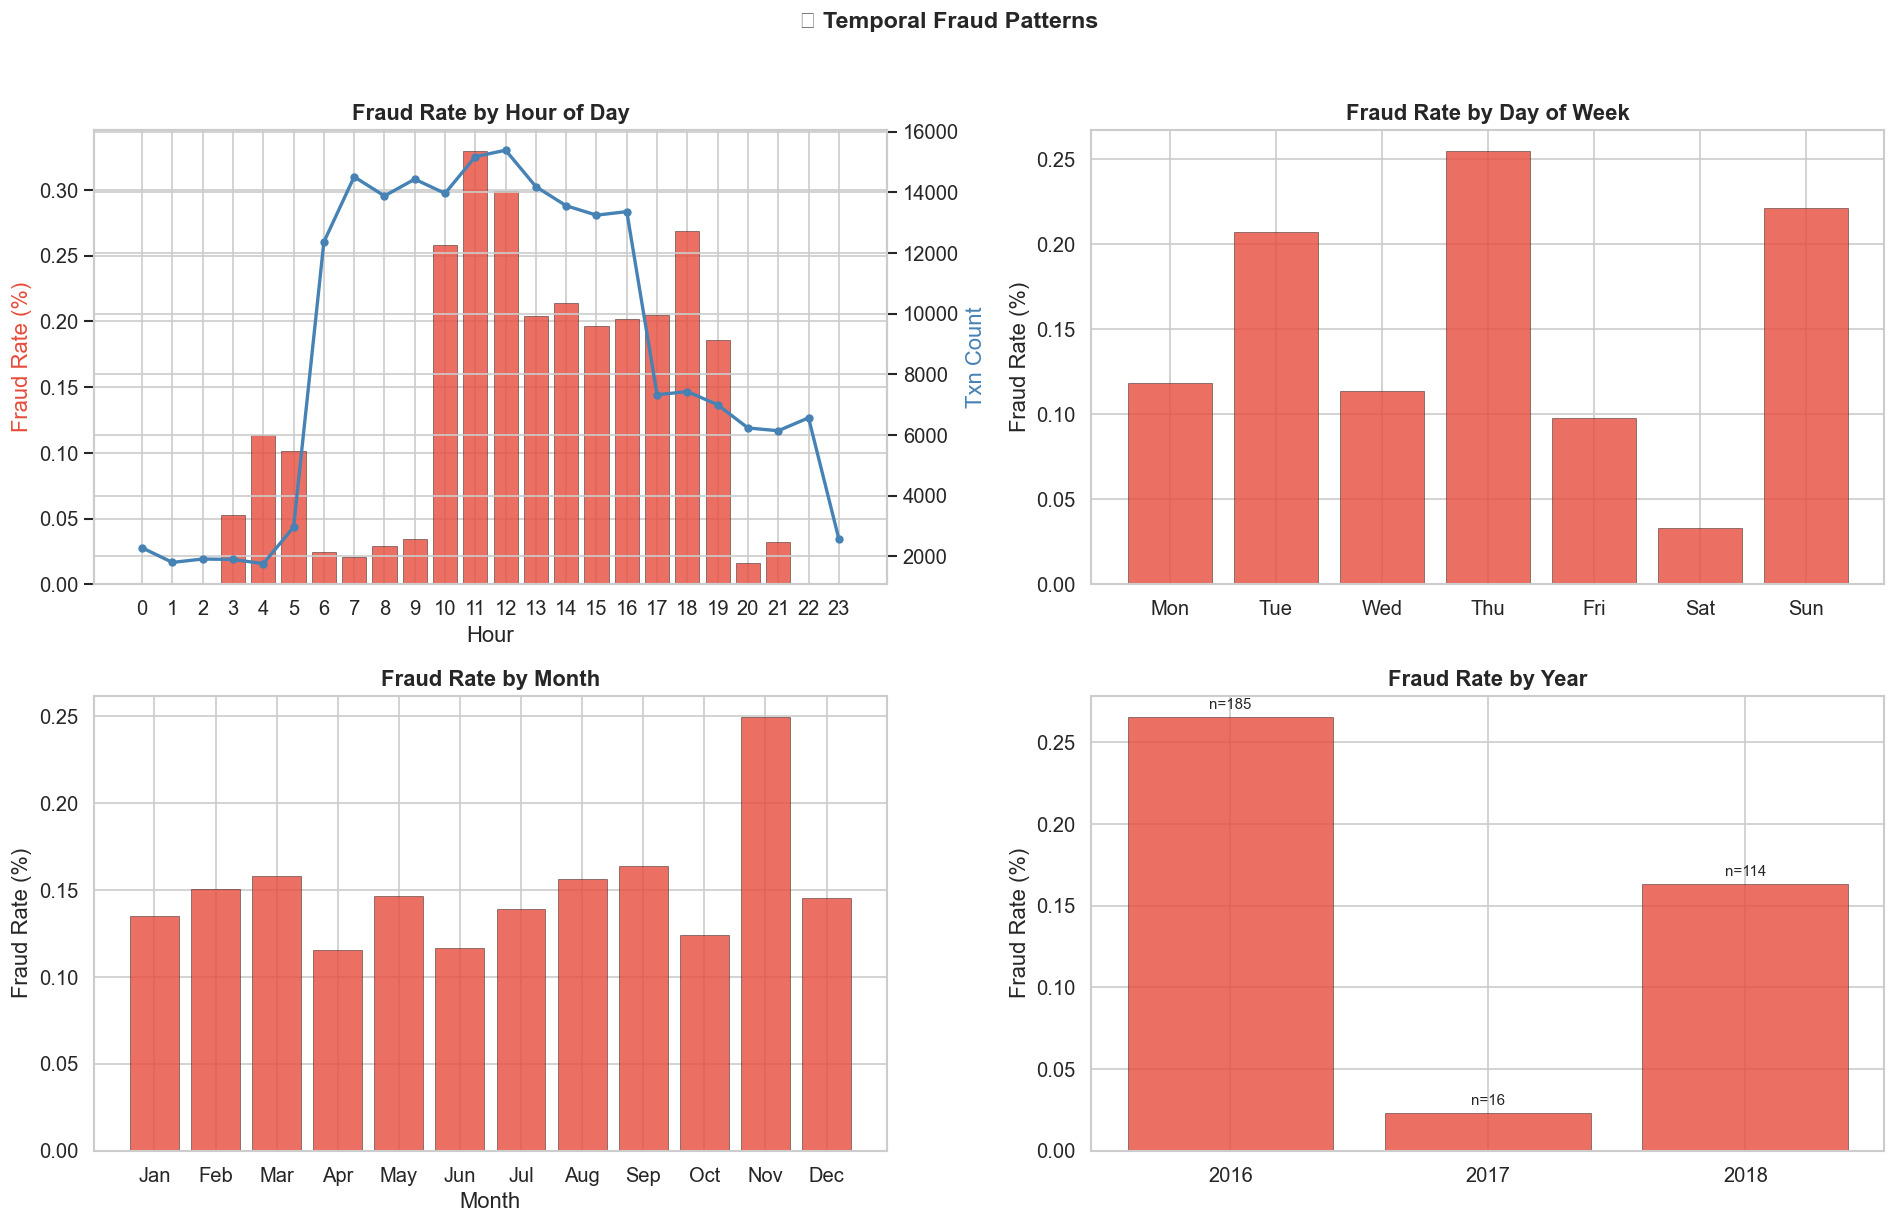

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 4a. Fraud rate by HOUR
hr_fraud = df.groupby('hour')['is_fraud'].mean() * 100
hr_count = df.groupby('hour')['is_fraud'].count()
ax = axes[0, 0]
ax.bar(hr_fraud.index, hr_fraud.values, color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
ax2 = ax.twinx()
ax2.plot(hr_count.index, hr_count.values, color='steelblue', linewidth=2, marker='o', markersize=4)
ax2.set_ylabel('Txn Count', color='steelblue')
ax.set_title('Fraud Rate by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Fraud Rate (%)', color='#e74c3c')
ax.set_xticks(range(0, 24))

# 4b. Fraud rate by DAY OF WEEK
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_fraud = df.groupby('day_name')['is_fraud'].mean().reindex(day_order) * 100
ax = axes[0, 1]
bars = ax.bar(range(7), dow_fraud.values, color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax.set_title('Fraud Rate by Day of Week', fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')

# 4c. Fraud rate by MONTH
mo_fraud = df.groupby('month')['is_fraud'].mean() * 100
ax = axes[1, 0]
ax.bar(mo_fraud.index, mo_fraud.values, color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
ax.set_title('Fraud Rate by Month', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# 4d. Fraud rate by YEAR
yr_fraud = df.groupby('year').agg(
    fraud_rate=('is_fraud', 'mean'),
    fraud_count=('is_fraud', 'sum'),
    total=('is_fraud', 'count')
)
yr_fraud['fraud_rate'] *= 100
ax = axes[1, 1]
ax.bar(yr_fraud.index.astype(str), yr_fraud['fraud_rate'], color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
ax.set_title('Fraud Rate by Year', fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
for i, (idx, row) in enumerate(yr_fraud.iterrows()):
    ax.text(i, row['fraud_rate'] + 0.005, f"n={int(row['fraud_count'])}", ha='center', fontsize=9)

plt.suptitle('⏰ Temporal Fraud Patterns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

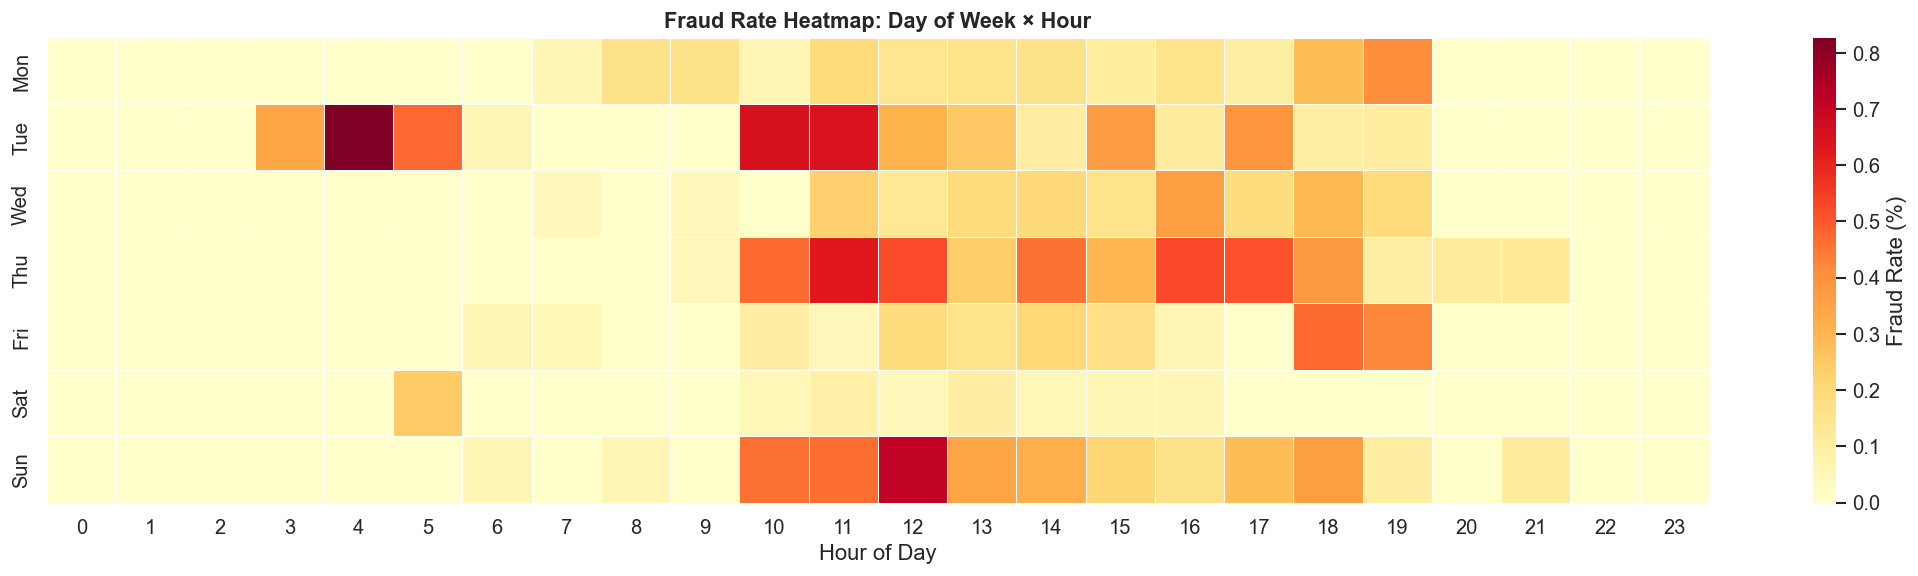

→ KEY INSIGHT: Look for late-night / early-morning fraud spikes — common in card-not-present fraud


In [9]:
# ── Heatmap: Hour × Day of Week fraud rate ──
pivot = df.pivot_table(values='is_fraud', index='dow', columns='hour', aggfunc='mean') * 100
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.2f', linewidths=0.5, ax=ax, cbar_kws={'label': 'Fraud Rate (%)'})
ax.set_title('Fraud Rate Heatmap: Day of Week × Hour', fontweight='bold', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
print('→ KEY INSIGHT: Look for late-night / early-morning fraud spikes — common in card-not-present fraud')

---
## 5 · Transaction Channel — use_chip

── Fraud Rate by Transaction Channel ──
                    fraud_rate_pct  fraud_count   total  volume_pct  avg_amount
use_chip                                                                       
Online Transaction          0.7324          185   25258        12.0   57.784792
Chip Transaction            0.0739          111  150302        71.6   40.396679
Swipe Transaction           0.0552           19   34440        16.4   40.791972


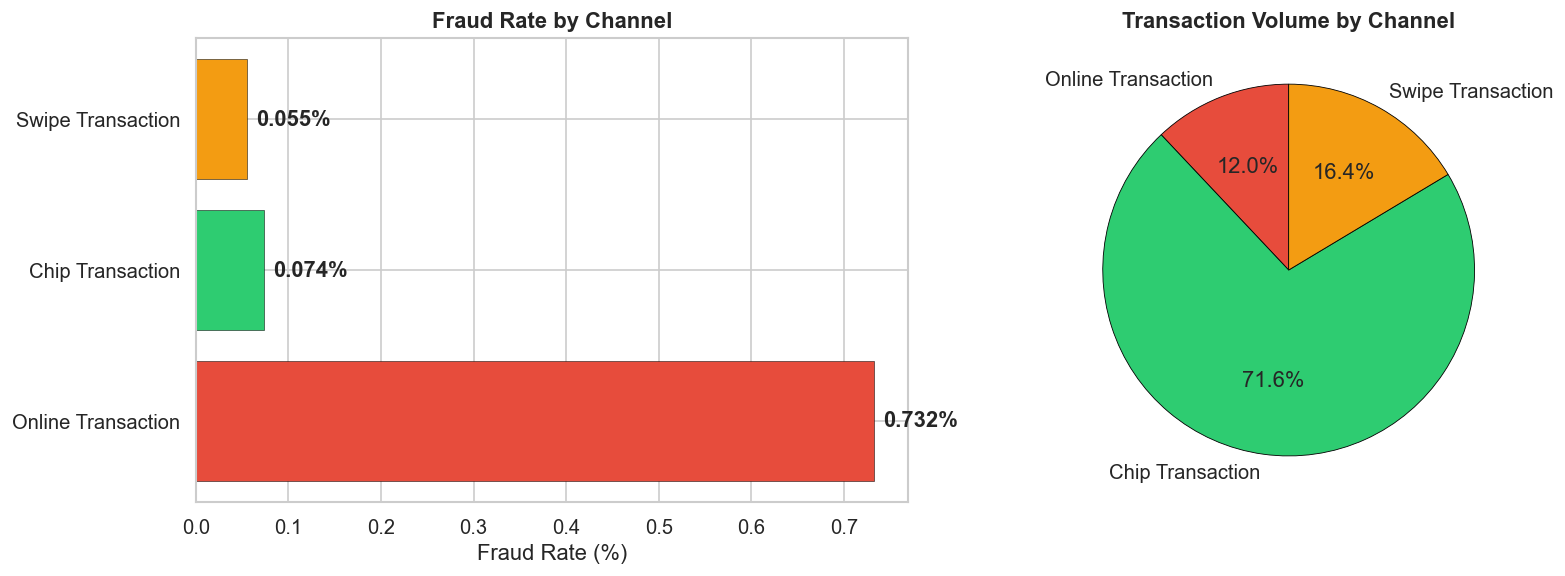


→ KEY INSIGHT: Online/Swipe transactions likely have higher fraud rate — no physical card verification


In [10]:
chip_fraud = df.groupby('use_chip').agg(
    fraud_rate=('is_fraud', 'mean'),
    fraud_count=('is_fraud', 'sum'),
    total=('is_fraud', 'count'),
    avg_amount=('amount_clean', 'mean')
).sort_values('fraud_rate', ascending=False)
chip_fraud['fraud_rate_pct'] = (chip_fraud['fraud_rate'] * 100).round(4)
chip_fraud['volume_pct'] = (chip_fraud['total'] / chip_fraud['total'].sum() * 100).round(1)

print('── Fraud Rate by Transaction Channel ──')
print(chip_fraud[['fraud_rate_pct', 'fraud_count', 'total', 'volume_pct', 'avg_amount']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate bars
ax = axes[0]
channel_colors = {'Online Transaction': '#e74c3c', 'Swipe Transaction': '#f39c12', 'Chip Transaction': '#2ecc71'}
colors_list = [channel_colors.get(c, '#95a5a6') for c in chip_fraud.index]
ax.barh(chip_fraud.index, chip_fraud['fraud_rate_pct'], color=colors_list, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Channel', fontweight='bold')
for i, v in enumerate(chip_fraud['fraud_rate_pct']):
    ax.text(v + 0.01, i, f'{v:.3f}%', va='center', fontweight='bold')

# Volume pie
ax = axes[1]
ax.pie(chip_fraud['total'], labels=chip_fraud.index, autopct='%1.1f%%', colors=colors_list,
       startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.5})
ax.set_title('Transaction Volume by Channel', fontweight='bold')

plt.tight_layout()
plt.show()
print('\n→ KEY INSIGHT: Online/Swipe transactions likely have higher fraud rate — no physical card verification')

---
## 6 · Merchant Category (MCC) Analysis

In [11]:
# Top MCC codes by fraud rate (min 50 transactions for statistical significance)
mcc_fraud = df.groupby(['mcc', 'mcc_desc']).agg(
    fraud_rate=('is_fraud', 'mean'),
    fraud_count=('is_fraud', 'sum'),
    total=('is_fraud', 'count'),
    avg_amount=('amount_clean', 'mean')
).reset_index()
mcc_fraud['fraud_rate_pct'] = (mcc_fraud['fraud_rate'] * 100).round(3)

# Filter for significance
mcc_sig = mcc_fraud[mcc_fraud['total'] >= 50].sort_values('fraud_rate', ascending=False)

print(f'── Top 15 MCC codes by Fraud Rate (min 50 txns) ──')
print(mcc_sig[['mcc', 'mcc_desc', 'fraud_rate_pct', 'fraud_count', 'total', 'avg_amount']].head(15).to_string(index=False))

# Bottom 10 (safest categories)
print(f'\n── Bottom 10 MCC codes (lowest fraud) ──')
print(mcc_sig[['mcc', 'mcc_desc', 'fraud_rate_pct', 'fraud_count', 'total']].tail(10).to_string(index=False))

── Top 15 MCC codes by Fraud Rate (min 50 txns) ──
 mcc                                          mcc_desc  fraud_rate_pct  fraud_count  total  avg_amount
5732                                Electronics Stores           9.524           12    126  161.889127
5816                             Digital Goods - Games           7.143            5     70  159.854857
3389                       Non-Precious Metal Services           4.571            8    175   77.365714
5932                                     Antique Shops           4.545            4     88  188.931364
4511                                          Airlines           3.636            2     55  679.759091
5712 Furniture, Home Furnishings, and Equipment Stores           3.509            2     57  333.533860
5094                        Precious Stones and Metals           2.667            2     75   50.775067
3405                                          Ironwork           2.542            3    118   74.381864
3509                 I

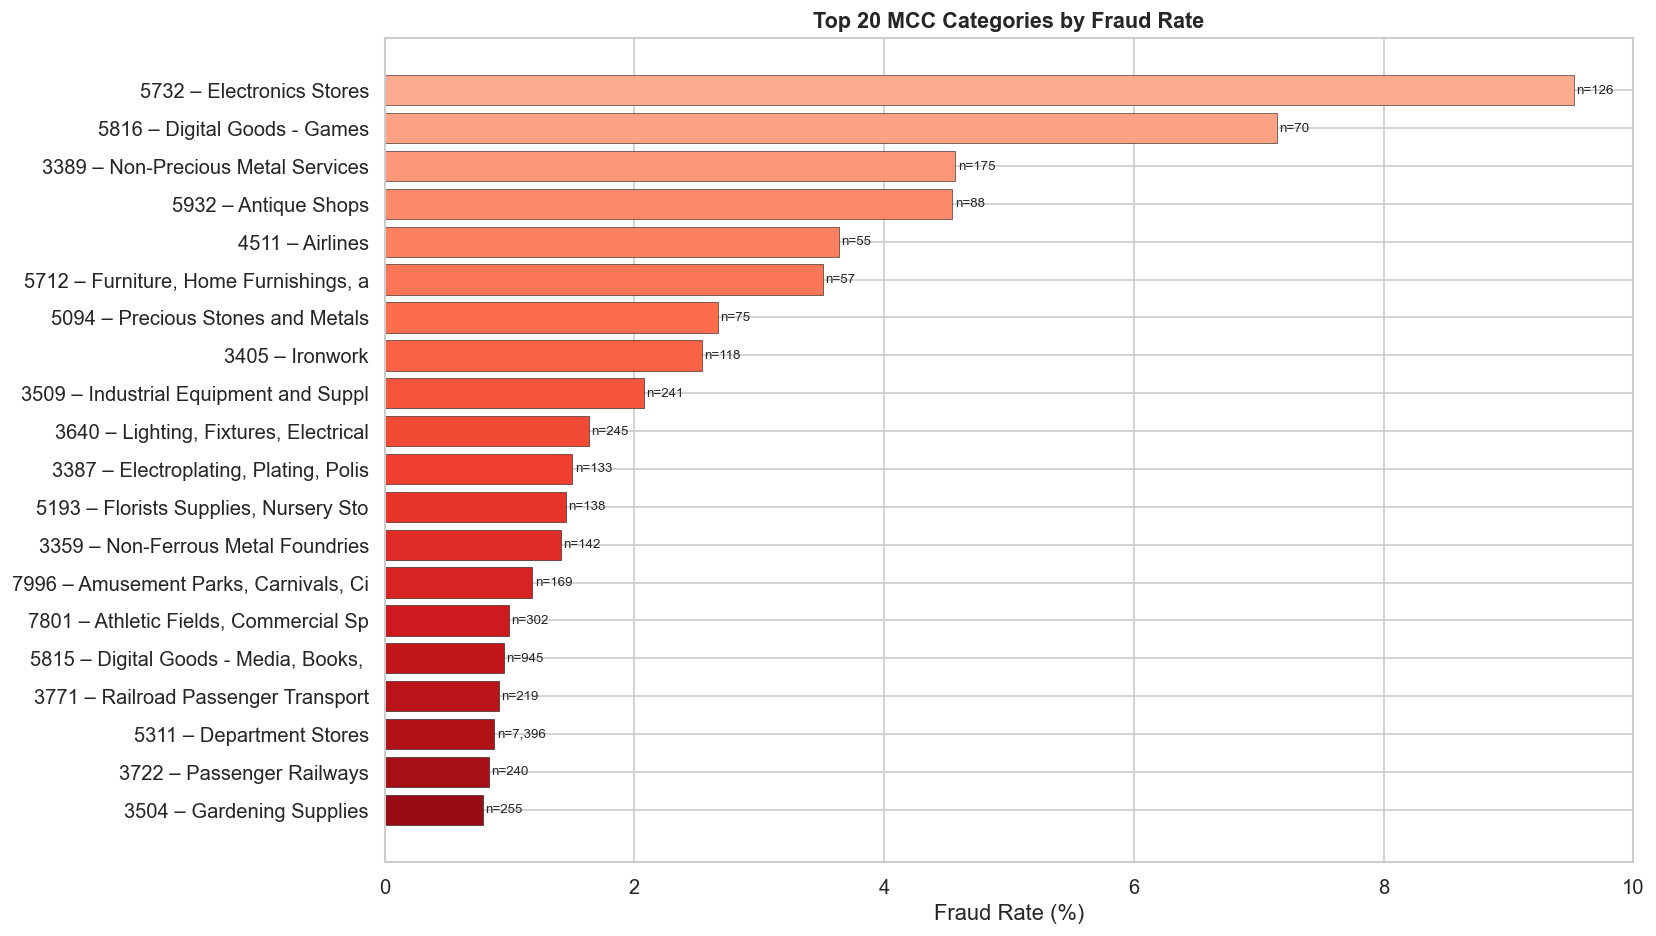

In [12]:
# Visual: Top 20 MCC codes by fraud rate
top_mcc = mcc_sig.head(20)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(
    [f"{row['mcc']} – {str(row['mcc_desc'])[:30]}" for _, row in top_mcc.iterrows()],
    top_mcc['fraud_rate_pct'],
    color=plt.cm.Reds(np.linspace(0.3, 0.9, len(top_mcc))),
    edgecolor='black', linewidth=0.3
)
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Top 20 MCC Categories by Fraud Rate', fontweight='bold', fontsize=13)
ax.invert_yaxis()
for i, (_, row) in enumerate(top_mcc.iterrows()):
    ax.text(row['fraud_rate_pct'] + 0.02, i, f"n={row['total']:,}", va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 7 · Geographic Analysis

posx and posy should be finite values


── Transaction Geography ──
             Segment  Count  Fraud Rate (%)
Domestic (in-person) 184569        0.070434
              Online  25431        0.727459
       International      0             NaN


posx and posy should be finite values


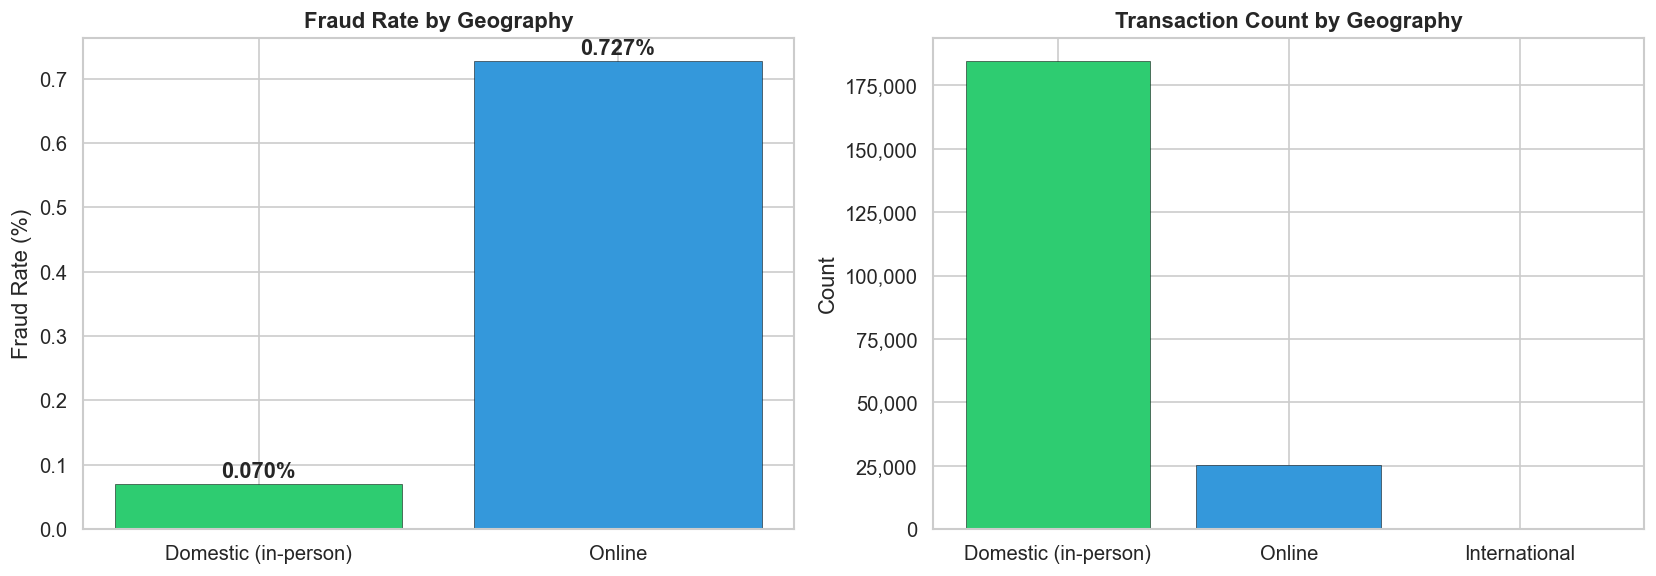

In [13]:
# ── Foreign vs Domestic transactions ──
# ONLINE and international txns have missing state/zip
df['is_online'] = (df['merchant_city'] == 'ONLINE').astype(int)
df['is_international'] = (
    df['merchant_state'].isna() & (df['merchant_city'] != 'ONLINE')
).astype(int)

geo_fraud = pd.DataFrame({
    'Segment': ['Domestic (in-person)', 'Online', 'International'],
    'Count': [
        ((~df.is_online.astype(bool)) & (~df.is_international.astype(bool))).sum(),
        df.is_online.sum(),
        df.is_international.sum()
    ],
    'Fraud Rate (%)': [
        df.loc[(~df.is_online.astype(bool)) & (~df.is_international.astype(bool)), 'is_fraud'].mean() * 100,
        df.loc[df.is_online == 1, 'is_fraud'].mean() * 100,
        df.loc[df.is_international == 1, 'is_fraud'].mean() * 100
    ]
})
print('── Transaction Geography ──')
print(geo_fraud.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#3498db', '#e74c3c']
axes[0].bar(geo_fraud['Segment'], geo_fraud['Fraud Rate (%)'], color=colors, edgecolor='black', linewidth=0.3)
axes[0].set_title('Fraud Rate by Geography', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(geo_fraud['Fraud Rate (%)']):
    axes[0].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontweight='bold')

axes[1].bar(geo_fraud['Segment'], geo_fraud['Count'], color=colors, edgecolor='black', linewidth=0.3)
axes[1].set_title('Transaction Count by Geography', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

In [14]:
# ── Top states by fraud rate (domestic only, min 100 txns) ──
state_fraud = df[df['merchant_state'].notna()].groupby('merchant_state').agg(
    fraud_rate=('is_fraud', 'mean'),
    fraud_count=('is_fraud', 'sum'),
    total=('is_fraud', 'count')
).reset_index()
state_fraud = state_fraud[state_fraud['total'] >= 100].sort_values('fraud_rate', ascending=False)
state_fraud['fraud_rate_pct'] = (state_fraud['fraud_rate'] * 100).round(3)

print(f'Top 15 states by fraud rate (min 100 txns):')
print(state_fraud[['merchant_state', 'fraud_rate_pct', 'fraud_count', 'total']].head(15).to_string(index=False))

# ── Distance between user home and merchant ──
# Approximate haversine placeholder — use lat/long from user vs merchant zip
print('\n→ NOTE: Could compute user-home ↔ merchant distance as a feature (lat/lon available)')

Top 15 states by fraud rate (min 100 txns):
merchant_state  fraud_rate_pct  fraud_count  total
         Italy          71.519          113    158
            HI           0.076            1   1314
            OH           0.053            4   7565
            MO           0.031            1   3209
            MD           0.031            1   3257
            SC           0.029            1   3406
            GA           0.018            1   5427
            NJ           0.017            1   5782
            MI           0.016            1   6303
            NY           0.015            2  13748
            NC           0.013            1   7646
            CA           0.010            2  20694
            TX           0.007            1  14947
            NV           0.000            0   1242
            OK           0.000            0   2441

→ NOTE: Could compute user-home ↔ merchant distance as a feature (lat/lon available)


---
## 8 · Card & User Profile Analysis

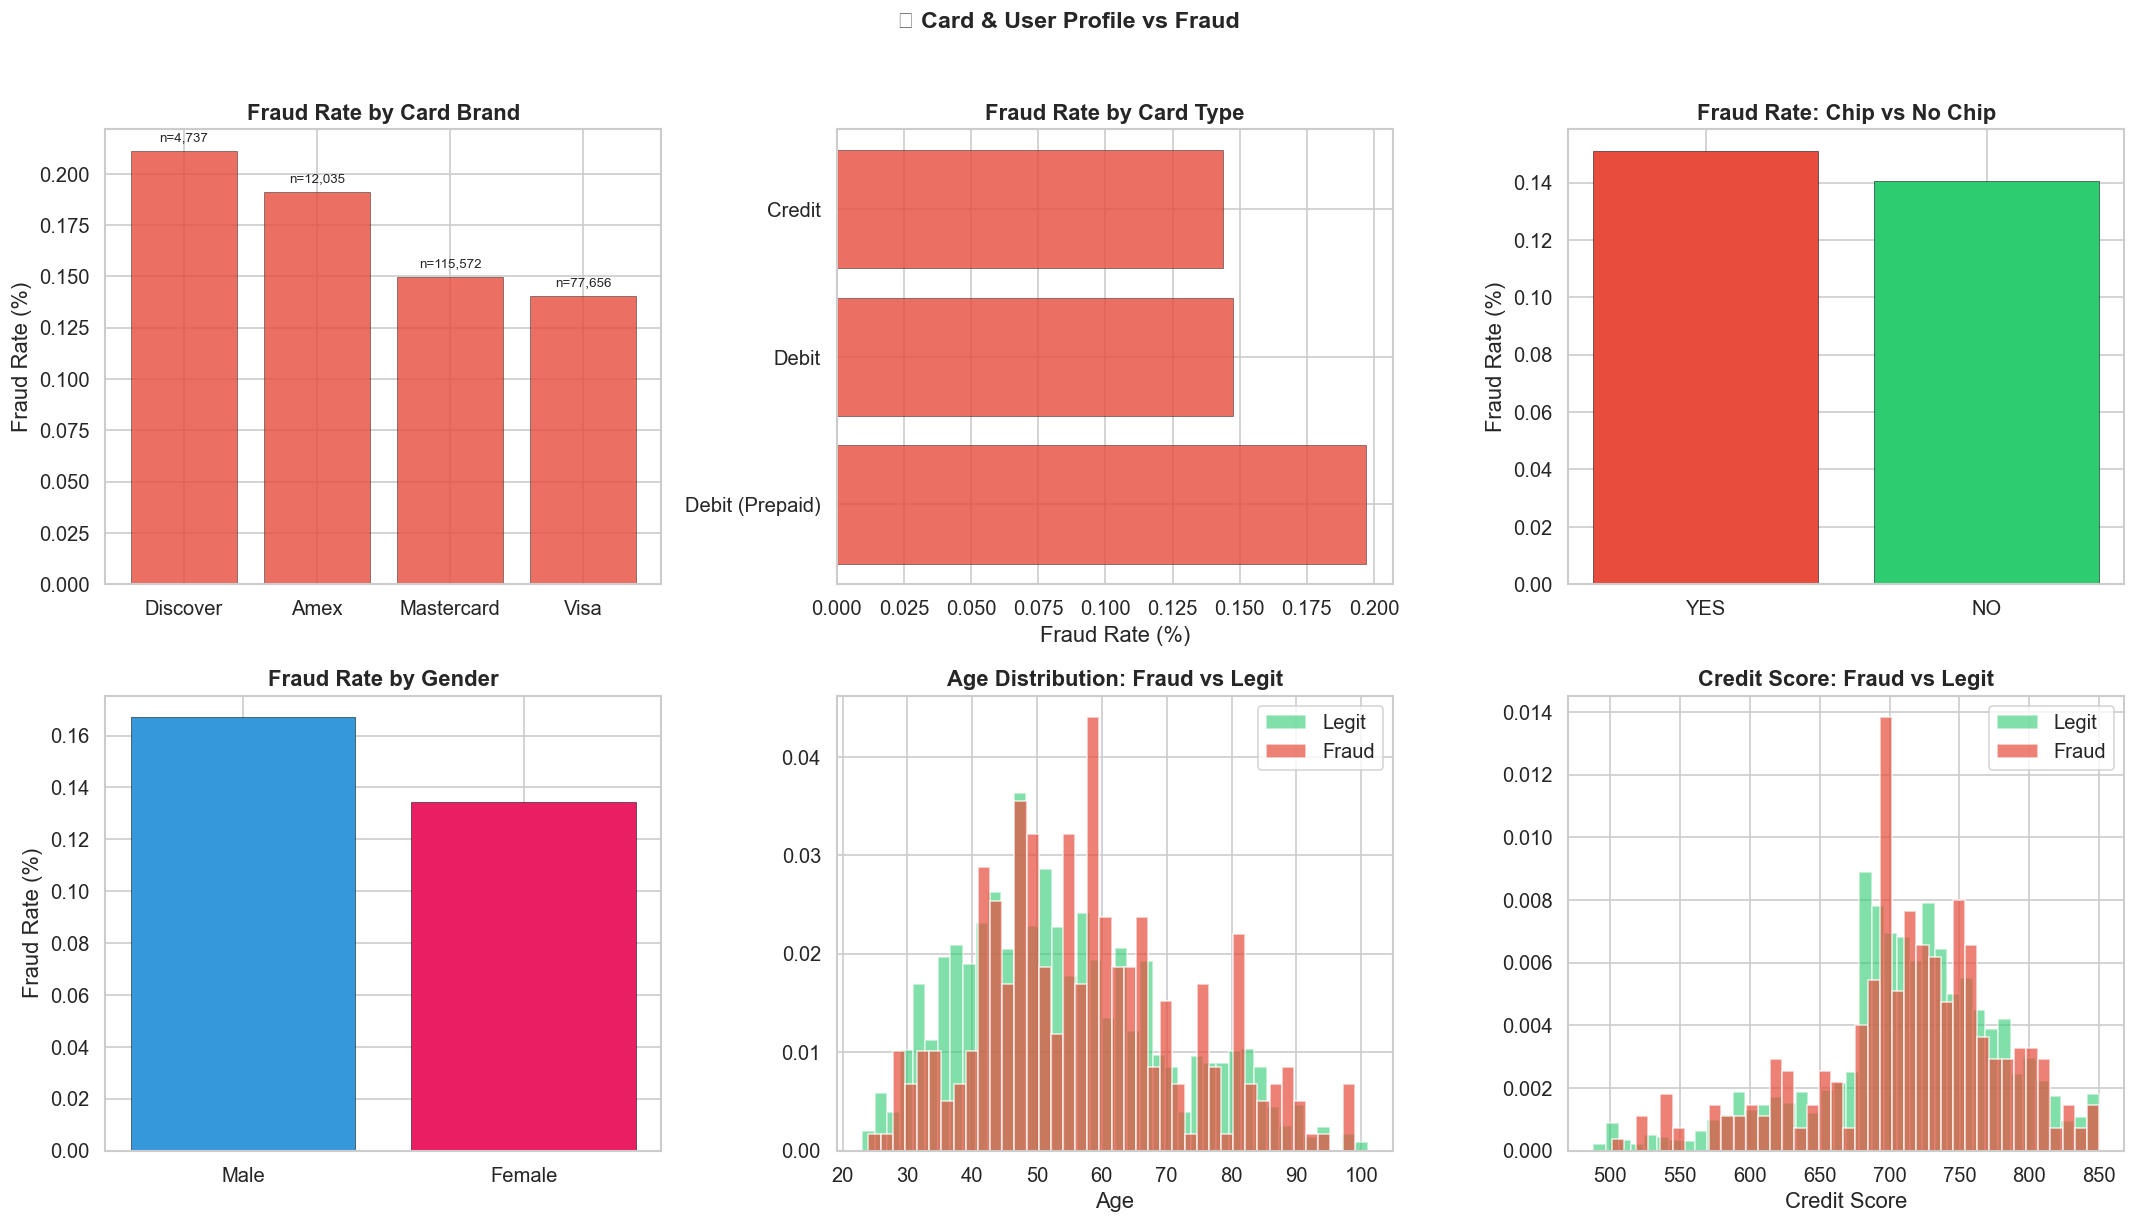

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 8a. Card brand
brand_fraud = df.groupby('card_brand')['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
brand_fraud['mean'] *= 100
ax = axes[0, 0]
ax.bar(brand_fraud.index, brand_fraud['mean'], color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
ax.set_title('Fraud Rate by Card Brand', fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
for i, (idx, row) in enumerate(brand_fraud.iterrows()):
    ax.text(i, row['mean'] + 0.005, f"n={int(row['count']):,}", ha='center', fontsize=8)

# 8b. Card type
type_fraud = df.groupby('card_type')['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
type_fraud['mean'] *= 100
ax = axes[0, 1]
ax.barh(type_fraud.index, type_fraud['mean'], color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Card Type', fontweight='bold')

# 8c. has_chip 
chip_flag = df.groupby('has_chip')['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
chip_flag['mean'] *= 100
ax = axes[0, 2]
ax.bar(chip_flag.index, chip_flag['mean'], color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.3)
ax.set_title('Fraud Rate: Chip vs No Chip', fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')

# 8d. Gender
gender_fraud = df.groupby('gender')['is_fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
gender_fraud['mean'] *= 100
ax = axes[1, 0]
ax.bar(gender_fraud.index, gender_fraud['mean'], color=['#3498db', '#e91e63'], edgecolor='black', linewidth=0.3)
ax.set_title('Fraud Rate by Gender', fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')

# 8e. Age distribution
ax = axes[1, 1]
ax.hist(legit_df['current_age'], bins=40, alpha=0.6, label='Legit', color='#2ecc71', density=True)
ax.hist(fraud_df['current_age'], bins=40, alpha=0.7, label='Fraud', color='#e74c3c', density=True)
ax.set_title('Age Distribution: Fraud vs Legit', fontweight='bold')
ax.set_xlabel('Age')
ax.legend()

# 8f. Credit score
ax = axes[1, 2]
ax.hist(legit_df['credit_score'], bins=40, alpha=0.6, label='Legit', color='#2ecc71', density=True)
ax.hist(fraud_df['credit_score'], bins=40, alpha=0.7, label='Fraud', color='#e74c3c', density=True)
ax.set_title('Credit Score: Fraud vs Legit', fontweight='bold')
ax.set_xlabel('Credit Score')
ax.legend()

plt.suptitle('🏦 Card & User Profile vs Fraud', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# ── Card on dark web analysis ──
darkweb = df.groupby('card_on_dark_web')['is_fraud'].agg(['mean', 'sum', 'count'])
darkweb['mean'] = (darkweb['mean'] * 100).round(3)
darkweb.columns = ['fraud_rate_%', 'fraud_count', 'total']
print('── Card on Dark Web vs Fraud ──')
print(darkweb)
print('\n→ CRITICAL: If dark web cards have elevated fraud, this is a very strong signal')

# ── Cards per client — multi-card users ──
cards_per_client = df.groupby('client_id')['card_id'].nunique()
df['n_cards_client'] = df['client_id'].map(cards_per_client)
ncards_fraud = df.groupby('n_cards_client')['is_fraud'].agg(['mean', 'count'])
ncards_fraud['mean'] = (ncards_fraud['mean'] * 100).round(3)
print('\n── Fraud rate by # cards per client ──')
print(ncards_fraud.head(10))

── Card on Dark Web vs Fraud ──
                  fraud_rate_%  fraud_count   total
card_on_dark_web                                   
No                        0.15          315  210000

→ CRITICAL: If dark web cards have elevated fraud, this is a very strong signal

── Fraud rate by # cards per client ──
                 mean  count
n_cards_client              
1               0.086  26656
2               0.127  52595
3               0.161  49787
4               0.165  46656
5               0.163  25723
6               0.323   7113
7               0.263   1139
8               0.000    331


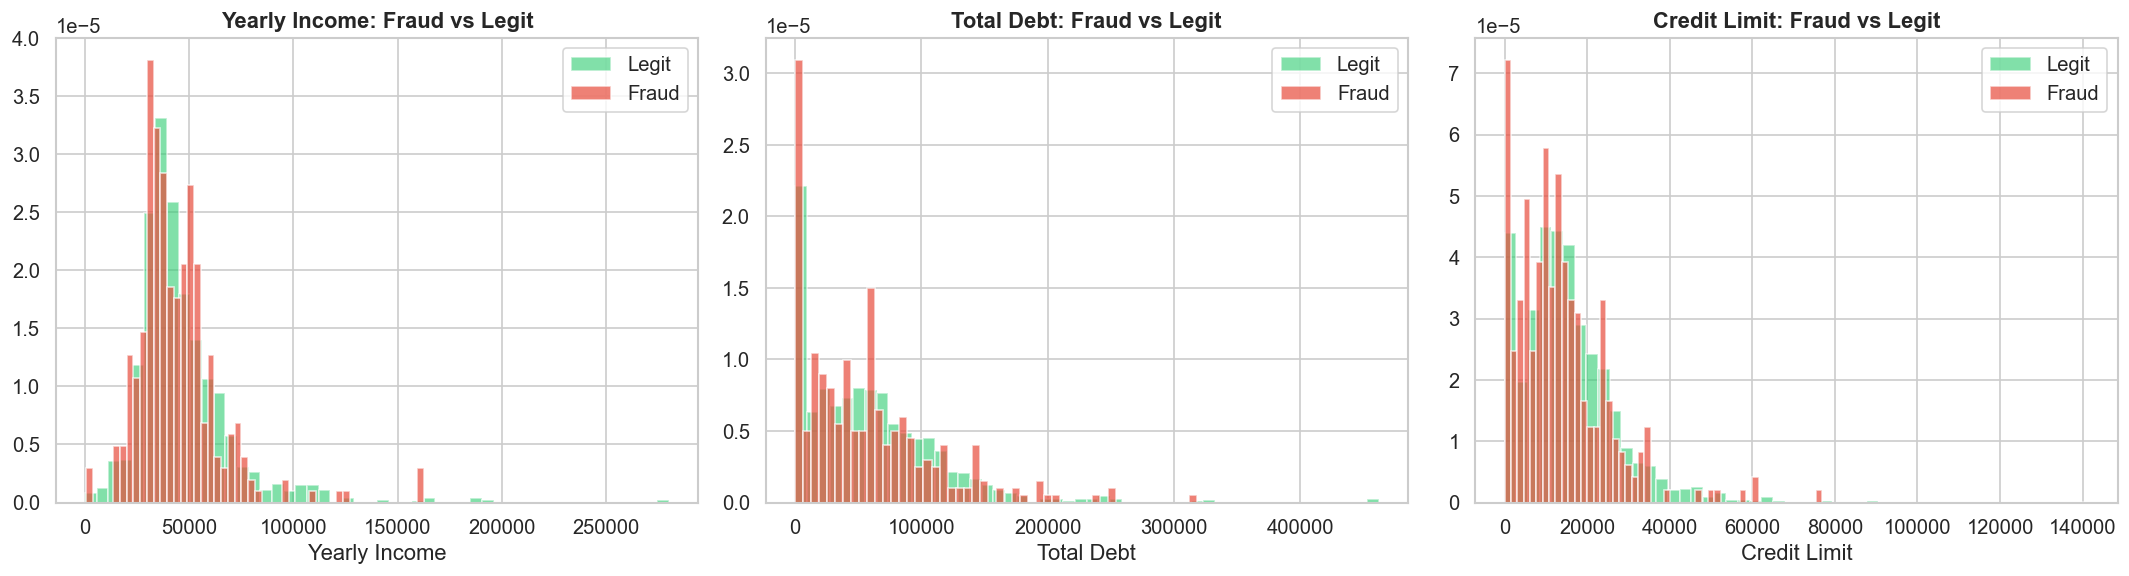

── Amount / Credit Limit ratio ──
Legit median: 0.0021
Fraud median: 0.0064


In [17]:
# ── Income & Debt vs Fraud ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, label) in enumerate([
    ('yearly_income_clean', 'Yearly Income'),
    ('total_debt_clean', 'Total Debt'),
    ('credit_limit_clean', 'Credit Limit')
]):
    ax = axes[i]
    ax.hist(legit_df[col].dropna(), bins=50, alpha=0.6, label='Legit', color='#2ecc71', density=True)
    ax.hist(fraud_df[col].dropna(), bins=50, alpha=0.7, label='Fraud', color='#e74c3c', density=True)
    ax.set_title(f'{label}: Fraud vs Legit', fontweight='bold')
    ax.set_xlabel(label)
    ax.legend()

plt.tight_layout()
plt.show()

# Amount as % of credit limit
df['amount_to_limit_ratio'] = df['amount_clean'] / df['credit_limit_clean'].replace(0, np.nan)
print('── Amount / Credit Limit ratio ──')
print(f"Legit median: {legit_df['amount_clean'].median() / legit_df['credit_limit_clean'].replace(0, np.nan).median():.4f}")
fraud_ratio = fraud_df['amount_clean'] / fraud_df['credit_limit_clean'].replace(0, np.nan)
print(f"Fraud median: {fraud_ratio.median():.4f}")

---
## 9 · Error Signals

── Fraud Rate by Error Type ──
                                       fraud_rate_pct  fraud_count   total
error_type                                                                
Bad CVV                                         2.062            2      97
Bad Expiration                                  1.010            1      99
Bad PIN                                         0.397            2     504
Technical Glitch                                0.246            1     406
Insufficient Balance                            0.150            3    2005
None                                            0.148          306  206727
Bad Card Number,Bad Expiration                  0.000            0       1
Bad Card Number,Insufficient Balance            0.000            0       2
Bad Card Number,Bad CVV                         0.000            0       1
Bad Expiration,Bad CVV                          0.000            0       1
Bad CVV,Insufficient Balance                    0.000            0   

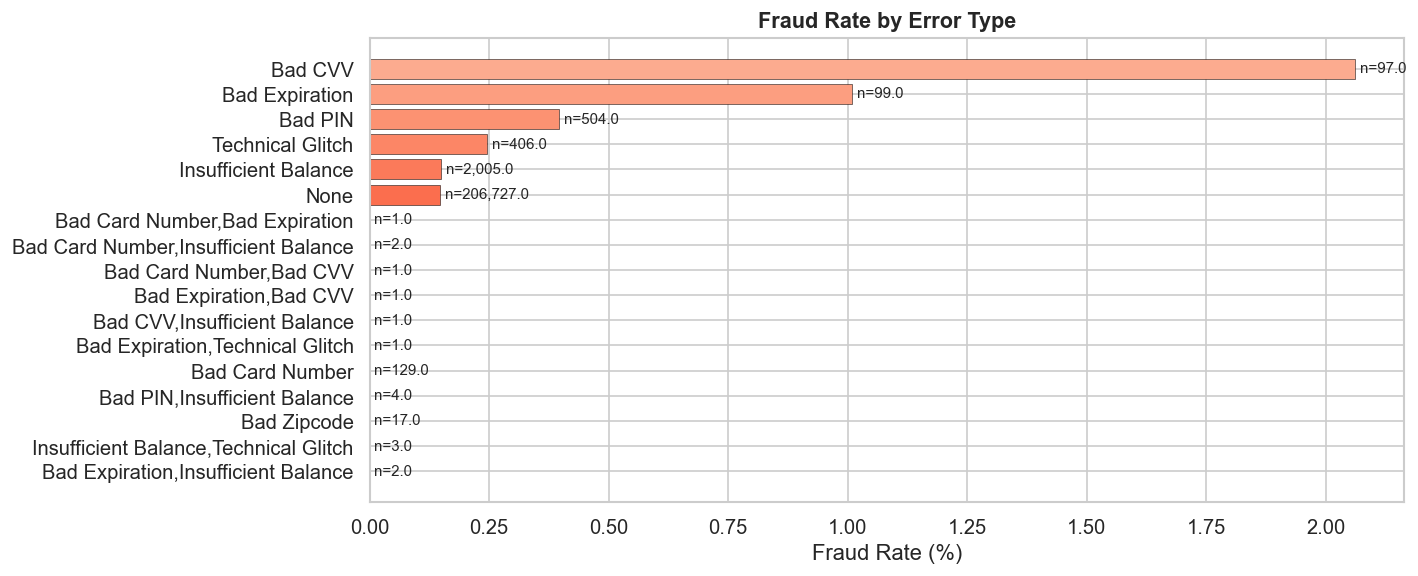

In [18]:
# ── Errors column analysis ──
df['has_error'] = df['errors'].notna().astype(int)
df['error_type'] = df['errors'].fillna('None')

error_fraud = df.groupby('error_type').agg(
    fraud_rate=('is_fraud', 'mean'),
    fraud_count=('is_fraud', 'sum'),
    total=('is_fraud', 'count')
).sort_values('fraud_rate', ascending=False)
error_fraud['fraud_rate_pct'] = (error_fraud['fraud_rate'] * 100).round(3)

print('── Fraud Rate by Error Type ──')
print(error_fraud[['fraud_rate_pct', 'fraud_count', 'total']].to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(error_fraud.index, error_fraud['fraud_rate_pct'],
        color=plt.cm.Reds(np.linspace(0.3, 0.9, len(error_fraud))),
        edgecolor='black', linewidth=0.3)
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Error Type', fontweight='bold', fontsize=13)
ax.invert_yaxis()
for i, (idx, row) in enumerate(error_fraud.iterrows()):
    ax.text(row['fraud_rate_pct'] + 0.01, i, f"n={row['total']:,}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 10 · Feature Correlation & Importance Preview

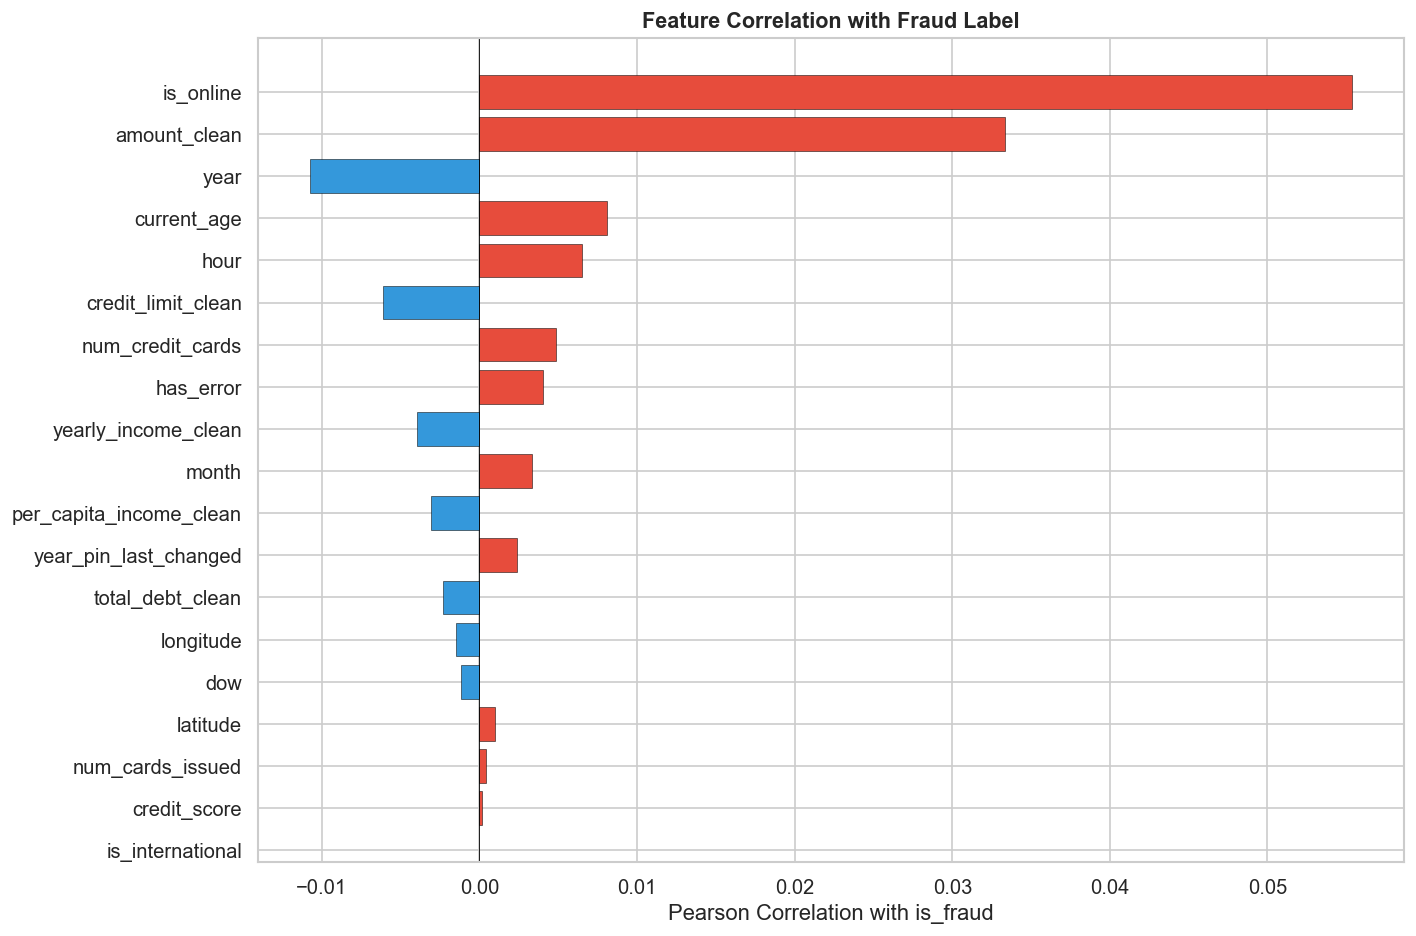


── Top correlations ──
is_online              0.055386
amount_clean           0.033326
year                  -0.010745
current_age            0.008112
hour                   0.006476
credit_limit_clean    -0.006120
num_credit_cards       0.004885
has_error              0.004063
yearly_income_clean   -0.003966
month                  0.003337


In [19]:
# ── Correlation of numeric features with is_fraud ──
numeric_cols = [
    'amount_clean', 'hour', 'dow', 'month', 'year',
    'current_age', 'credit_score', 'num_credit_cards',
    'credit_limit_clean', 'yearly_income_clean', 'total_debt_clean',
    'per_capita_income_clean', 'num_cards_issued',
    'year_pin_last_changed', 'has_error', 'is_online', 'is_international',
    'latitude', 'longitude'
]

# Correlation with target
corr_with_fraud = df[numeric_cols + ['is_fraud']].corr()['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_fraud.values]
ax.barh(corr_with_fraud.index, corr_with_fraud.values, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Pearson Correlation with is_fraud')
ax.set_title('Feature Correlation with Fraud Label', fontweight='bold', fontsize=13)
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\n── Top correlations ──')
print(corr_with_fraud.head(10).to_string())

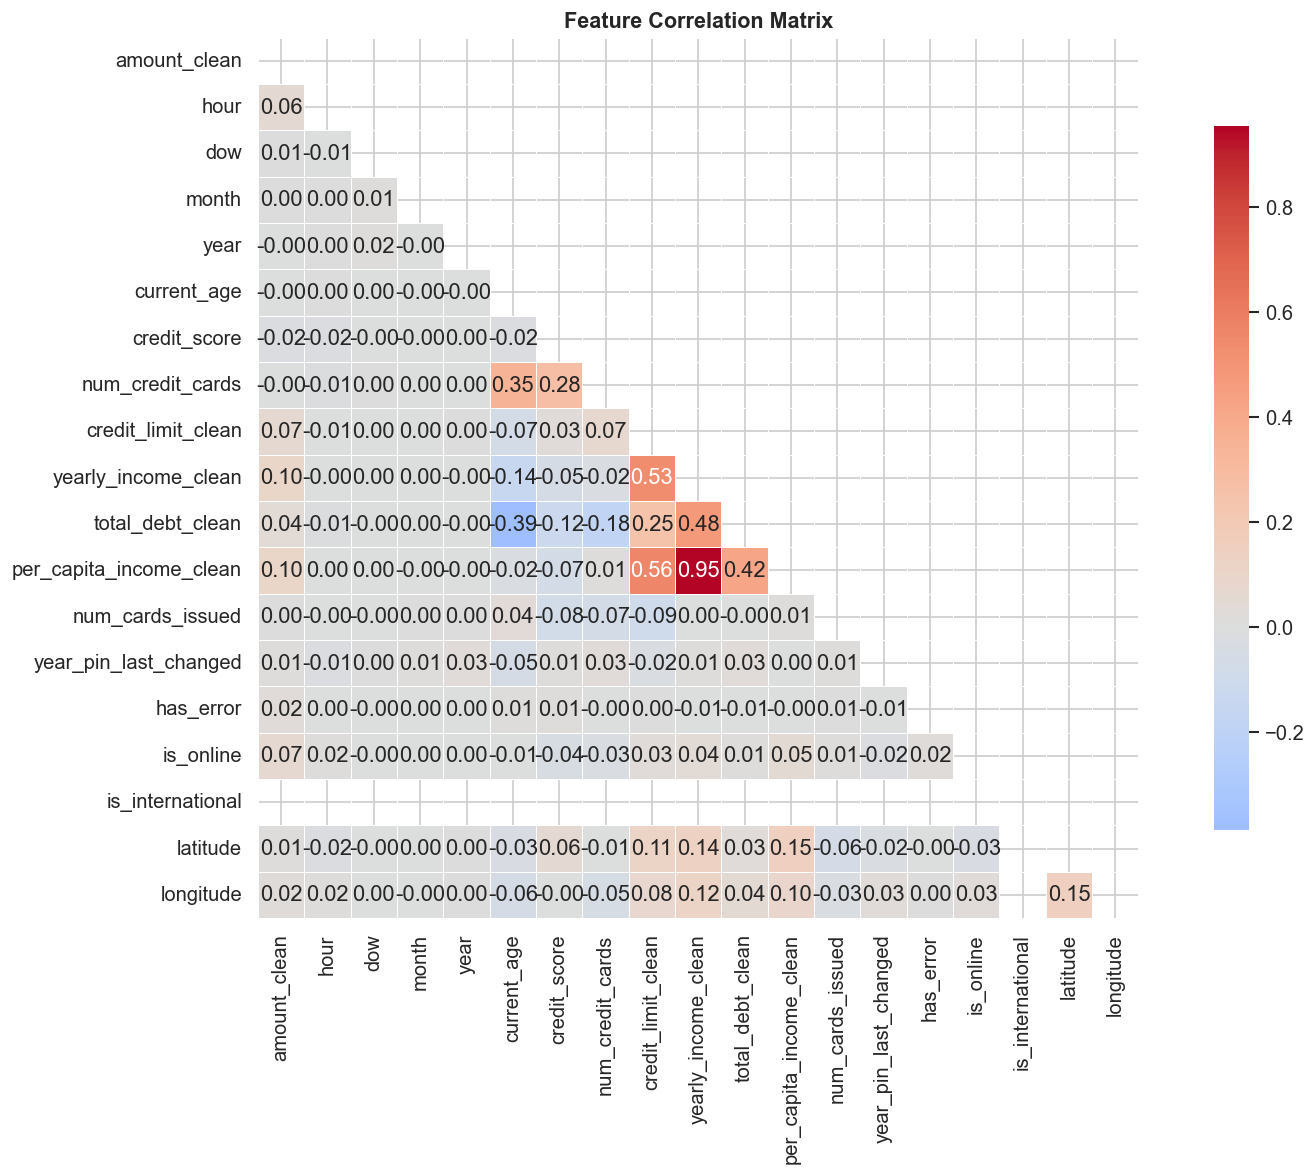


⚠️  Highly correlated feature pairs (|r| > 0.7):
  yearly_income_clean ↔ per_capita_income_clean: r=0.954
→ Consider dropping one from each pair to avoid multicollinearity


In [20]:
# ── Inter-feature correlation heatmap (detect multicollinearity) ──
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5, ax=ax,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i, j], 3)))

if high_corr:
    print('\n⚠️  Highly correlated feature pairs (|r| > 0.7):')
    for a, b, r in high_corr:
        print(f'  {a} ↔ {b}: r={r}')
    print('→ Consider dropping one from each pair to avoid multicollinearity')
else:
    print('✓ No high multicollinearity detected')

In [21]:
# ── Repeat-merchant & velocity features (preview) ──
# Transactions per client
txn_per_client = df.groupby('client_id').agg(
    n_txns=('transaction_id', 'count'),
    n_fraud=('is_fraud', 'sum'),
    n_merchants=('merchant_id', 'nunique'),
    avg_amount=('amount_clean', 'mean'),
    std_amount=('amount_clean', 'std'),
    n_online=('is_online', 'sum'),
    n_states=('merchant_state', 'nunique')
).reset_index()
txn_per_client['fraud_rate'] = txn_per_client['n_fraud'] / txn_per_client['n_txns']

print('── Client-level aggregates ──')
print(f'Clients with ANY fraud: {(txn_per_client.n_fraud > 0).sum()} / {len(txn_per_client)}')
print(f'Max fraud txns per client: {txn_per_client.n_fraud.max()}')
print(f'Avg txns per client: {txn_per_client.n_txns.mean():.1f}')

# Do some clients have much higher fraud rates?
fraud_clients = txn_per_client[txn_per_client.n_fraud > 0].sort_values('fraud_rate', ascending=False)
print(f'\nTop 10 fraud-prone clients:')
print(fraud_clients[['client_id', 'n_txns', 'n_fraud', 'fraud_rate', 'n_merchants', 'n_states']].head(10).to_string(index=False))

── Client-level aggregates ──
Clients with ANY fraud: 221 / 852
Max fraud txns per client: 6
Avg txns per client: 246.5

Top 10 fraud-prone clients:
 client_id  n_txns  n_fraud  fraud_rate  n_merchants  n_states
      1649      45        2    0.044444           26         1
       619     167        6    0.035928           53        11
       783     111        3    0.027027           54         9
      1879      74        2    0.027027           42         7
      1267     156        4    0.025641           63        12
      1709     128        3    0.023438           44         6
       201      86        2    0.023256           43         8
      1095     132        3    0.022727           55        13
      1882     132        3    0.022727           56         8
       100     153        3    0.019608           54        12


---
## 11 · Feature Engineering Roadmap

Based on EDA findings, the following features should be engineered for the model:

### 🔴 High-Signal (build first)
| Feature | Rationale |
|---|---|
| `is_online` | Online txns typically have elevated fraud |
| `is_international` | Cross-border = higher risk |
| `hour_sin` / `hour_cos` | Cyclical encoding of time — capture late-night patterns |
| `amount_zscore` | Per-client normalized amount (deviation from their norm) |
| `amount_to_limit_ratio` | Transaction size relative to credit limit |
| `card_on_dark_web` | Binary high-signal flag |
| `error_type_encoded` | One-hot or target-encoded error types |
| `mcc_fraud_rate` | Historical fraud rate per MCC (target encoding) |

### 🟡 Velocity / Behavioral (second pass)
| Feature | Rationale |
|---|---|
| `txn_count_last_1h` | Rapid-fire transactions = suspicious |
| `txn_count_last_24h` | Daily velocity |
| `time_since_last_txn` | Very short gaps = bot/automated fraud |
| `n_unique_merchants_24h` | Sudden merchant diversity |
| `amount_vs_rolling_avg` | Amount deviation from client's rolling average |
| `n_states_24h` | Geographic impossibility detection |

### 🟢 Profile (contextualize)
| Feature | Rationale |
|---|---|
| `age_bin` | Discretized age groups |
| `credit_score_bin` | Risk tiers |
| `debt_to_income` | Financial stress proxy |
| `card_age_months` | Newer cards = higher risk |
| `card_brand + card_type` | Interaction features |
| `pin_freshness` | Years since PIN change |

### ⚙️ Modeling Notes
- **Class imbalance:** 1:666 ratio → use `class_weight='balanced'`, SMOTE, or focal loss
- **Metric:** Use **PR-AUC** (not ROC-AUC) due to severe imbalance
- **Validation:** Temporal split (train on earlier, validate on later) to avoid data leakage
- **Evaluation set:** 90K rows in `evaluation_features.csv` — same schema, no labels

In [22]:
# ── Summary statistics for the report ──
print('=' * 60)
print('         EDA SUMMARY — KEY FINDINGS')
print('=' * 60)
print(f'\n📊 Dataset: {len(df):,} transactions, {df.client_id.nunique():,} clients, {df.card_id.nunique():,} cards')
print(f'🎯 Fraud: {df.is_fraud.sum()} / {len(df):,} = {df.is_fraud.mean()*100:.3f}% (ratio 1:{int((1-df.is_fraud.mean())/df.is_fraud.mean())})')
print(f'📅 Date range: {df.datetime.min()} → {df.datetime.max()}')
print(f'💰 Amount range: ${df.amount_clean.min():.2f} → ${df.amount_clean.max():.2f}')
print(f'🌐 Online txns: {df.is_online.sum():,} ({df.is_online.mean()*100:.1f}%)')
print(f'✈️  International: {df.is_international.sum():,} ({df.is_international.mean()*100:.1f}%)')
print(f'⚠️  Txns with errors: {df.has_error.sum():,} ({df.has_error.mean()*100:.1f}%)')
print(f'\n🔑 Clients with ≥1 fraud: {(txn_per_client.n_fraud > 0).sum()}')
print(f'🃏 Unique MCC codes: {df.mcc.nunique()}')
print(f'🏪 Unique merchants: {df.merchant_id.nunique():,}')
print('\n' + '=' * 60)

         EDA SUMMARY — KEY FINDINGS

📊 Dataset: 210,000 transactions, 852 clients, 2,538 cards
🎯 Fraud: 315 / 210,000 = 0.150% (ratio 1:665)
📅 Date range: 2016-01-01 00:29:00 → 2018-12-31 23:31:00
💰 Amount range: $-500.00 → $2775.67
🌐 Online txns: 25,431 (12.1%)
✈️  International: 0 (0.0%)
⚠️  Txns with errors: 3,273 (1.6%)

🔑 Clients with ≥1 fraud: 221
🃏 Unique MCC codes: 109
🏪 Unique merchants: 13,576

